# Get estimates of recent demography history in AFR, AMR, EAS, FIN, SAS ancestries of gnomAD v4

In [1]:
# --- make parent folder importable ---
import sys
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))  # points to Paper_SFS/

# --- usual imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy as sc
from scipy.integrate import quad
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from scipy.signal import find_peaks
from scipy.stats import gaussian_kde
from scipy.stats import gmean, linregress, norm, beta, uniform, lognorm
from scipy.integrate import simpson, trapezoid
from scipy.optimize import minimize, curve_fit
from scipy.special import logsumexp
from scipy.integrate import simpson
from scipy import stats
import glob
import os
import math
import dask
import dask.dataframe as dd
import re
import dask.bag as db
import csv
from tqdm import tqdm
from dask.diagnostics import ProgressBar
from concurrent.futures import ProcessPoolExecutor
import time
import joblib
from joblib import Parallel, delayed, parallel_backend
import multiprocessing
import pickle
import random
import json

# --- import your project modules (files in Paper_SFS/) ---
import Gen_SFS_with_s_demography
import plot_SFS

# (optional) pull specific functions
# from Gen_SFS_with_s import calc_SFS_k
# from plot_SFS import plot_sfs


In [2]:
def load_syn_anc(demography, MR_val, data_root="../Data/syn_anc"):
    """
    Load synonymous ancestry-specific data for a given demography.

    Parameters
    ----------
    demography : str - e.g. 'NFE', 'AFR', 'EAS'
    data_root : str or Path - Path to Data/syn_anc directory

    Returns
    -------
    df : pandas.DataFrame
    allele_number : allele_number mode for that demography
    """
    data_root = Path(data_root)

    matches = sorted(data_root.glob(f"{demography}_*.txt.gz"))

    if len(matches) == 0:
        raise FileNotFoundError(f"No files found for demography '{demography}' in {data_root}")

    if len(matches) > 1:
        raise ValueError(f"Multiple files found for demography '{demography}':\n" + "\n".join(str(p.name) for p in matches))

    file_path = matches[0]

    # Extract the number e.g. "24590" from "NFE_24590.txt.gz"
    filename = os.path.basename(file_path)
    num_str = filename.split("_")[1].split(".")[0]   # split on "_" then remove ".txt.gz"
    allele_number = int(num_str)

    # Load the file
    df = pd.read_csv(file_path, sep="\t", compression="gzip")

    df_syn_filtered = df[(df['allele_count']<=5000) & (df['MR'].isin(MR_val))].reset_index(drop = True)
    df_syn_filtered = df_syn_filtered.copy()
    df_syn_filtered['log_MR'] = np.log(df_syn_filtered['MR'])
    MR_to_rank = {mr: idx for idx, mr in enumerate(sorted(MR_val))}
    df_syn_filtered['MR_rank'] = df_syn_filtered['MR'].map(MR_to_rank)

    return df_syn_filtered, allele_number

In [3]:
# Load NFE demography parameters
df_mu_var_p = pd.read_csv("../Mutation_rate_estimation/param_mut_rate/results_mu_var_p_NFE.txt", sep = '\t')
df_mu_var_p

,MR,p_mu,mean_mu,var_mu,max_loglikelihood
0,0.013,0.000023,0.000047,3.339915e-14,-177863.380436
1,0.020,0.000078,0.000071,3.339915e-14,-842807.318386
2,0.030,0.000065,0.000104,3.339915e-14,-827840.316209
3,0.041,0.000026,0.000139,3.339915e-14,-671669.636024
4,0.051,0.000059,0.000175,3.339915e-14,-658984.217696
...,...,...,...,...,...
93,2.813,0.010184,0.008505,4.983876e-06,-68233.165295
94,2.996,0.007725,0.008838,7.301899e-06,-33010.139318
95,3.219,0.004311,0.009499,9.582311e-06,-10710.353121
96,3.507,0.000526,0.011040,2.060630e-05,-2535.492724


In [4]:
# Get Roulette values for which residual variance is negligible
MR_val = np.array([0.013, 0.02 , 0.03 , 0.041, 0.051, 0.062, 0.073, 0.083, 0.094,
                   0.105, 0.117, 0.128, 0.139, 0.151, 0.163, 0.174, 0.186, 0.198, 0.211])

In [5]:
df_mu_var_p_sorted = (
    df_mu_var_p[df_mu_var_p["MR"].isin(MR_val)]
    .sort_values("MR")
)

mean_mu_values = df_mu_var_p_sorted["mean_mu"].values / (4 * 14448)

print(mean_mu_values)

[8.15619114e-10 1.23177878e-09 1.80164913e-09 2.40314336e-09
 3.02220117e-09 3.66560374e-09 4.30949103e-09 4.97580929e-09
 5.61832964e-09 6.23765977e-09 6.82446161e-09 7.43460078e-09
 8.05709690e-09 8.68424856e-09 9.33606320e-09 9.87083574e-09
 1.05880959e-08 1.12143637e-08 1.19968247e-08]


## Likelihood for demography estimation

In [6]:
def log_likelihood_demography_low_mu(params, df_syn, mu_values, demography, n, model, cutoff = None, num_bins = None, kmax = 5000):

    """
    Computes the negative log-likelihood for given values of demography parameters params. Syn SFS contains only mean mu as a parameter
    - `params`: demography params
    - `df_syn`: DataFrame with allele_count and MR_rank for specific ancestry
    """
    
    SFS_each, _, _, _ = Gen_SFS_with_s_demography.compute_SFS_parallel(mu_values, [0], demography, n, params, model, cutoff, num_bins, kmax)

    # Get k values as integer array
    k_indices = df_syn["allele_count"].astype(int).values
    # Get mu_indices as integer array
    mu_indices = df_syn["MR_rank"].astype(int).values
    # Get counts values as integer array
    counts = df_syn["count"].astype(int).values

    # Compute likelihood
    log_likelihood =  np.log(SFS_each[mu_indices, 0, k_indices] + 1e-300) * counts

    logL = np.sum(log_likelihood)  # Sum log-likelihood across all loci

    # print(f"Current params: {params} | -Log-Likelihood: {-logL}")
    
    return -logL  # Return negative log-likelihood for minimization


In [7]:
# Running ancestry and different epochs

In [9]:
# Dictionary of initial parameters by (demography, epoch)
initial_params_dict = {
    ("AFR", 2): [3.65948269e+06, 1.78655366e+02, 3.03888494e+05, 8.37330431e+02],
    ("SAS", 2): [3.65948269e+06, 1.78655366e+02, 3.03888494e+05, 8.37330431e+02],
    ("AMR", 2): [3.65948269e+06, 1.78655366e+02, 3.03888494e+05, 8.37330431e+02],
    ("EAS", 2): [3.65948269e+06, 1.78655366e+02, 3.03888494e+05, 8.37330431e+02],
    ("FIN", 2): [8.76433889e+05, 3.05226133e+01, 3.66281710e+04, 3.25174597e+02],
    ("AFR", 3): [3e6, 1.25e2, 3e5, 4e2, 3e4, 9e2],
    ("SAS", 3): [3e6, 1.25e2, 3e5, 4e2, 3e4, 9e2],
    ("AMR", 3): [3e6, 1.25e2, 3e5, 4e2, 3e4, 9e2],
    ("EAS", 3): [3e6, 1.25e2, 3e5, 4e2, 3e4, 9e2],
    ("FIN", 3): [5e5, 5e1, 1e5, 4e2, 7e3, 9e2],
    ("AFR", 4): [5e+06, 1e+02, 7e5, 2.5e2, 2e5, 6e2, 2e4, 1.1e3],
    ("SAS", 4): [5e+06, 1e+02, 7e5, 2.5e2, 2e5, 6e2, 2e4, 1.1e3],
    ("AMR", 4): [5e+06, 1e+02, 7e5, 2.5e2, 2e5, 6e2, 2e4, 1.1e3],
    ("EAS", 4): [5e+06, 1e+02, 7e5, 2.5e2, 2e5, 6e2, 2e4, 1.1e3],
    ("FIN", 4): [5e+06, 1e+02, 7e5, 2.5e2, 2e5, 6e2, 2e4, 1.1e3],
    ("AFR", 6): [5e+06, 5e1,   1e6, 1e2,   5e5, 2e2, 2e5, 4e2, 8e4, 6e2, 1e4, 1.1e3],
    ("SAS", 6): [5e+06, 5e1,   1e6, 1e2,   5e5, 2e2, 2e5, 4e2, 8e4, 6e2, 1e4, 1.1e3],
    ("AMR", 6): [5e+06, 5e1,   1e6, 1e2,   5e5, 2e2, 2e5, 4e2, 8e4, 6e2, 1e4, 1.1e3],
    ("EAS", 6): [5e+06, 5e1,   1e6, 1e2,   5e5, 2e2, 2e5, 4e2, 8e4, 6e2, 1e4, 1.1e3],
    ("FIN", 6): [8e+05, 5e1,   5e5, 1e2,   1e5, 2e2, 1e5, 4e2, 7e4, 6e2, 1e4, 1.1e3],
    ("all", 1): [2e7]
}

# Dictionary of parameter bounds by (demography, epoch)
bounds_dict = {
    ("AFR", 2): [(5e5, 2e7), (1e1, 3e2), (2e4, 5e5), (3e2,1.2e3)],
    ("SAS", 2): [(5e5, 2e7), (1e1, 3e2), (2e4, 5e5), (3e2,1.2e3)],
    ("AMR", 2): [(5e5, 2e7), (1e1, 3e2), (2e4, 5e5), (3e2,1.2e3)],
    ("EAS", 2): [(5e5, 2e7), (1e1, 3e2), (2e4, 5e5), (3e2,1.2e3)],
    ("FIN", 2): [(1e5, 2e7), (5, 2e2)  , (1e4, 5e5), (2e2,1e3)],
    ("AFR", 3): [(5e5, 2e7), (1e1, 2.5e2),(1e4, 5e5), (2.5e2,6e2) , (3e3, 1e5), (6e2,1.2e3)],
    ("SAS", 3): [(5e5, 2e7), (1e1, 2.5e2),(1e4, 5e5), (2.5e2,6e2) , (3e3, 1e5), (6e2,1.2e3)],
    ("AMR", 3): [(5e5, 2e7), (1e1, 2.5e2),(1e4, 5e5), (2.5e2,6e2) , (3e3, 1e5), (6e2,1.2e3)],
    ("EAS", 3): [(5e5, 2e7), (1e1, 2.5e2),(1e4, 5e5), (2.5e2,6e2) , (3e3, 1e5), (6e2,1.2e3)],
    ("FIN", 3): [(1e5, 2e7), (5, 1e2)    ,(5e3, 3e5), (1e2,4e2)   , (3e3, 1e5), (4e2,1e3)],
    ("AFR", 4): [(7e5, 2e7), (1e1, 1.5e2), (1e5, 8e5), (1.5e2, 4e2), (1e4, 5e5), (4e2, 8e2), (3e3, 5e4), (8e2, 1.2e3)],
    ("SAS", 4): [(7e5, 2e7), (1e1, 1.5e2), (1e5, 8e5), (1.5e2, 4e2), (1e4, 5e5), (4e2, 8e2), (3e3, 5e4), (8e2, 1.2e3)],
    ("AMR", 4): [(7e5, 2e7), (1e1, 1.5e2), (1e5, 8e5), (1.5e2, 4e2), (1e4, 5e5), (4e2, 8e2), (3e3, 5e4), (8e2, 1.2e3)],
    ("EAS", 4): [(7e5, 2e7), (1e1, 1.5e2), (1e5, 8e5), (1.5e2, 4e2), (1e4, 5e5), (4e2, 8e2), (3e3, 5e4), (8e2, 1.2e3)],
    ("FIN", 4): [(1e5, 1e7), (5, 1.5e2), (5e4, 8e5), (1.5e2, 4e2), (7e3, 2e5), (4e2, 8e2), (1e3, 5e4), (8e2, 1e3)],
    ("AFR", 6): [(1e6, 2e7), (1e1, 7.5e1), (5e5, 5e6), (7.5e1, 1.5e2), (1e5, 1e6), (1.5e2, 3e2), (2e4, 8e5), (3e2, 5e2), (2e4, 5e5), (5e2, 7.5e2), (3e3, 5e4), (7.5e2, 1.2e3)],
    ("SAS", 6): [(1e6, 2e7), (1e1, 7.5e1), (5e5, 5e6), (7.5e1, 1.5e2), (1e5, 1e6), (1.5e2, 3e2), (2e4, 8e5), (3e2, 5e2), (2e4, 5e5), (5e2, 7.5e2), (3e3, 5e4), (7.5e2, 1.2e3)],
    ("AMR", 6): [(1e6, 2e7), (1e1, 7.5e1), (5e5, 5e6), (7.5e1, 1.5e2), (1e5, 1e6), (1.5e2, 3e2), (2e4, 8e5), (3e2, 5e2), (2e4, 5e5), (5e2, 7.5e2), (3e3, 5e4), (7.5e2, 1.2e3)],
    ("EAS", 6): [(1e6, 2e7), (1e1, 7.5e1), (5e5, 5e6), (7.5e1, 1.5e2), (1e5, 1e6), (1.5e2, 3e2), (2e4, 8e5), (3e2, 5e2), (2e4, 5e5), (5e2, 7.5e2), (3e3, 5e4), (7.5e2, 1.2e3)],
    ("FIN", 6): [(1e6, 2e7), (5, 7.5e1), (3e5, 5e6), (7.5e1, 1.5e2), (8e4, 1e6), (1.5e2, 3e2), (2e4, 6e5), (3e2, 5e2), (3e3, 5e5), (5e2, 7.5e2), (3e3, 5e4), (7.5e2, 1e3)],
    ("all", 1): [(5e6, 3.5e7)]
}


In [12]:
def run_demography_fit(demography, epoch_no, df_syn_dem, mean_mu_values, AN, model, bounds_dict, init_dict, output_file, cutoff=None, num_bins=None, kmax=5000):
    """
    Runs optimization for a given demography & epoch and stores results.

    Parameters:
        demography : str
        epoch_no : int (2,4,6,...)
        df_syn_dem : dataframe for this ancestry
        mean_mu_values : array of scaled mutation rates
        AN : allele number
        model : "original" or "diffusion"
        bounds_dict : dict mapping (demography, epoch_no) → bounds
        init_dict : dict mapping (demography, epoch_no) → initial_params
        output_file : str or Path where results are appended
    """

    key = (demography, epoch_no)

    if key not in bounds_dict:
        raise KeyError(f"No bounds defined for {key}")
    if key not in init_dict:
        raise KeyError(f"No initial_params defined for {key}")

    bounds = bounds_dict[key]
    initial_params = init_dict[key]

    print(f"\n=== Running optimization for {demography}, {epoch_no} epochs ===")
    print(f"Initial params = {initial_params}")
    print(f"Bounds = {bounds}")

    # Run optimization
    result = minimize(
        log_likelihood_demography_low_mu,
        initial_params,
        args=(df_syn_dem, mean_mu_values, demography, AN, model, cutoff, num_bins),
        bounds=bounds,
        method="Nelder-Mead",
        options={"disp": True, "fatol": 1e-5, "xatol": 1e-5}
    )

    # Prepare an output entry
    record = {
        "demography": demography,
        "epoch_no": epoch_no,
        "params": result.x.tolist(),
        "fun": float(-result.fun),
        "success": bool(result.success),
    }

    # Append to output file
    output_file = Path(output_file)
    output_file.parent.mkdir(parents=True, exist_ok=True)

    if output_file.exists():
        all_records = json.loads(output_file.read_text())
    else:
        all_records = []

    all_records.append(record)

    output_file.write_text(json.dumps(all_records, indent=2))

    print(f"Saved results to {output_file}")

    return result


### Run epoch = 2 for all demographies

In [10]:
for dem in ["AFR", "SAS", "AMR", "EAS", "FIN"]:
    df_syn_dem, AN = load_syn_anc(dem, MR_val, data_root="../Data/syn_anc")
    run_demography_fit(
        demography=dem,
        epoch_no=2,
        df_syn_dem=df_syn_dem,
        mean_mu_values=mean_mu_values,
        AN=AN,
        model="original",
        bounds_dict=bounds_dict,
        init_dict=initial_params_dict,
        output_file="demography_results.json"
    )


=== Running optimization for AFR, 2 epochs ===
Initial params = [3659482.69, 178.655366, 303888.494, 837.330431]
Bounds = [(500000.0, 20000000.0), (10.0, 300.0), (20000.0, 500000.0), (300.0, 1200.0)]
Optimization terminated successfully.
         Current function value: 4292121.362663
         Iterations: 238
         Function evaluations: 477
Saved results to demography_results.json

=== Running optimization for AMR, 2 epochs ===
Initial params = [3659482.69, 178.655366, 303888.494, 837.330431]
Bounds = [(500000.0, 20000000.0), (10.0, 300.0), (20000.0, 500000.0), (300.0, 1200.0)]
Optimization terminated successfully.
         Current function value: 2954941.983199
         Iterations: 233
         Function evaluations: 464
Saved results to demography_results.json

=== Running optimization for EAS, 2 epochs ===
Initial params = [3659482.69, 178.655366, 303888.494, 837.330431]
Bounds = [(500000.0, 20000000.0), (10.0, 300.0), (20000.0, 500000.0), (300.0, 1200.0)]
Optimization terminated

/tmp/ipykernel_1887510/480957492.py:32: OptimizeWarning: Initial guess is not within the specified bounds
  result = minimize(


Optimization terminated successfully.
         Current function value: 1221238.090639
         Iterations: 241
         Function evaluations: 475
Saved results to demography_results.json


### Run epoch = 3 for all demographies

In [ ]:
for dem in ["AFR", "SAS", "AMR", "EAS", "FIN"]:
    df_syn_dem, AN = load_syn_anc(dem, MR_val, data_root="../Data/syn_anc")
    run_demography_fit(
        demography=dem,
        epoch_no=3,
        df_syn_dem=df_syn_dem,
        mean_mu_values=mean_mu_values,
        AN=AN,
        model="original",
        bounds_dict=bounds_dict,
        init_dict=initial_params_dict,
        output_file="demography_results.json"
    )


=== Running optimization for AFR, 3 epochs ===
Initial params = [3000000.0, 125.0, 300000.0, 400.0, 30000.0, 900.0]
Bounds = [(500000.0, 20000000.0), (10.0, 250.0), (10000.0, 500000.0), (250.0, 600.0), (3000.0, 100000.0), (600.0, 1200.0)]


### Plotting demography

In [15]:
def load_demography_result(json_file, demography, epoch_no):
    with open(json_file, "r") as f:
        records = json.load(f)
    for rec in records:
        if rec["demography"] == demography and rec["epoch_no"] == epoch_no:
            return rec
    raise ValueError(f"No entry for demography={demography}, epoch={epoch_no} in {json_file}")

def _step_xy_from_Ne_Te(Ne, Te, t_end=0.0):
    """
    Build x,y arrays for ax.step(..., where="post") for a piecewise-constant demography.

    Ne: (m,) effective sizes for each epoch
    Te: (m,) left edges of each epoch, in descending order (ancient -> recent)
        Example: Te = [T0, T1, ..., T_{m-1}] where T0 > T1 > ... > T_{m-1} >= t_end
    t_end: rightmost time to end at (default 0.0 = present)

    Returns:
      T_plot, Ne_plot suitable for ax.step(T_plot, Ne_plot, where="post")
    """
    Ne = np.asarray(Ne, dtype=float)
    Te = np.asarray(Te, dtype=float)

    if Ne.ndim != 1 or Te.ndim != 1 or len(Ne) != len(Te):
        raise ValueError("Ne and Te must be 1D arrays of the same length.")
    if len(Ne) == 0:
        return np.array([]), np.array([])
    if not np.all(np.diff(Te) < 0):
        raise ValueError("Te must be strictly decreasing (ancient -> present).")
    if Te[-1] < t_end:
        raise ValueError("Last Te must be >= t_end.")

    # Build right edges (append t_end)
    Te_edges = np.append(Te, float(t_end))

    # Step arrays: duplicate each epoch value over its interval
    T_plot = np.repeat(Te_edges, 2)[1:-1]   # [Te0, Te1, Te1, Te2, ..., Te_{m-1}, t_end]
    Ne_plot = np.repeat(Ne, 2)              # [Ne0, Ne0, Ne1, Ne1, ..., Ne_{m-1}, Ne_{m-1}]

    return T_plot, Ne_plot


def plot_demography_split_fixed_new(
    Ne, Te, n_new, ax, color, label=None, lw=2.2,
    fixed_ls="--", new_ls="-"
):
    """
    Plot demography where:
      - earliest (fixed) segments are dashed
      - last n_new segments (newly added epochs) are solid

    Assumes Te is ancient -> present (strictly decreasing).
    """
    Ne = np.asarray(Ne, dtype=float)
    Te = np.asarray(Te, dtype=float)

    if n_new <= 0 or n_new > len(Ne):
        T, Y = _step_xy_from_Ne_Te(Ne, Te, t_end=0.0)
        ax.step(T, Y, where="post", color=color, lw=lw, ls=fixed_ls, label=label)
        return

    n_fixed = len(Ne) - n_new
    boundary = Te[n_fixed]  # left edge of the first "new" segment

    # ---- fixed part: end at boundary (NOT at 0) ----
    if n_fixed > 0:
        Ne_fixed = Ne[:n_fixed]
        Te_fixed = Te[:n_fixed]
        T_fix, Y_fix = _step_xy_from_Ne_Te(Ne_fixed, Te_fixed, t_end=boundary)
        ax.step(T_fix, Y_fix, where="post", color=color, lw=lw, ls=fixed_ls)

    # ---- new part: start at boundary and end at 0 ----
    Ne_new = Ne[n_fixed-1:]
    Te_new = Te[n_fixed-1:]
    
    T_new, Y_new = _step_xy_from_Ne_Te(Ne_new, Te_new, t_end=0.0)
    ax.step(T_new, Y_new, where="post", color=color, lw=lw, ls=new_ls, label=label)


# ----------------------------------------------------------
# Fixed ancestry colors
# ----------------------------------------------------------
ANCESTRY_COLORS = {
    "NFE":     "#1f77b4",
    "AFR":     "#d62728",
    "SAS":     "#9467bd",
    "EAS":     "#000000",
    "AMR":     "#8c564b",
    "FIN":     "#ff7f0e",
    "all":     "#2ca02c",
    "de novo": "#FFC000"
}

def plot_multiple_demographies_epochs(demographies, epoch_list, json_file, output_svg=None, figsize=(6, 4), lw=2.2):
    """
    For non-NFE demographies:
      - previous/fixed part dashed
      - newly added epochs (epoch_no segments) solid
    For NFE/all:
      - just a single solid line
    """
    fig, ax = plt.subplots(figsize=figsize)

    for dem in demographies:
        color = ANCESTRY_COLORS.get(dem, "black")

        for epoch_no in epoch_list:

            # ---- NFE / all: plot once ----
            if dem in ("NFE", "all"):
                if epoch_no != epoch_list[0]:
                    continue
                Ne, Te, _ = Gen_SFS_with_s_demography.prepare_demography(demography=dem, params=None, model="original")
                T, Y = _step_xy_from_Ne_Te(Ne, Te)
                ax.step(T, Y, where="post", color=color, lw=lw, ls="--", label=dem)
                continue

            # ---- load fitted demography ----
            try:
                rec = load_demography_result(json_file, demography=dem, epoch_no=epoch_no)
            except ValueError:
                continue

            params = rec["params"]
            Ne, Te, _ = Gen_SFS_with_s_demography.prepare_demography(demography=dem, params=params, model="original")

            # dashed fixed + solid new (last epoch_no segments)
            # label only once per demography (on first epoch plotted)
            label = dem if epoch_no == epoch_list[0] else None

            plot_demography_split_fixed_new(
                Ne=Ne, Te=Te, n_new=epoch_no,
                ax=ax, color=color, label=label, lw=lw,
                fixed_ls="--", new_ls="-"
            )

    # Axis formatting
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.invert_xaxis()
    ax.set_xlabel("Time (generations ago)", fontsize=14)
    ax.set_ylabel("Effective population size (Ne)", fontsize=14)

    ax.tick_params(direction="out", length=6, width=1.2)

    ax.legend(frameon=False, fontsize=10)
    plt.tight_layout()

    if output_svg is not None:
        plt.savefig(output_svg, dpi=300, format="svg")
        print(f"Saved: {output_svg}")

    plt.show()
    return fig, ax


Saved: ../Figures/demographies_epoch_3_all.svg


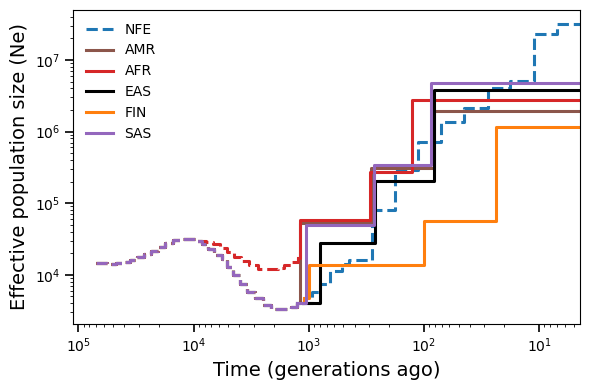

In [16]:
# Epoch = 3 plots 
_, _ = plot_multiple_demographies_epochs(demographies=["NFE", "AMR", "AFR", "EAS", "FIN", "SAS"],
                                  epoch_list=[3], json_file="demography_results.json"    
                                  ,output_svg = "../Figures/demographies_epoch_3_all.svg"
                                 )

# Scratch work

In [14]:
def remove_demography_entry(json_file, demography, epoch_no):

    json_file = Path(json_file)

    if not json_file.exists():
        print("File does not exist:", json_file)
        return

    records = json.loads(json_file.read_text())

    # Keep only entries NOT matching the one you want to remove
    new_records = [
        rec for rec in records
        if not (rec.get("demography") == demography and rec.get("epoch_no") == epoch_no)
    ]

    json_file.write_text(json.dumps(new_records, indent=2))
    print(f"Removed entry: demography={demography}, epoch_no={epoch_no} from {json_file}")


In [15]:
remove_demography_entry("demography_results.json", "all", 1)

Removed entry: demography=all, epoch_no=1 from demography_results.json


In [7]:
# Load the GnomAD dataset
demography = "AFR"
df_syn_dem, AN = load_syn_anc(demography, MR_val, data_root="../Data/syn_anc")

In [11]:
# Work on df_syn_filetered_dataframe
initial_params = [3.65948269e+06, 1.78655366e+02, 3.03888494e+05, 8.37330431e+02]
# bounds = [(5e5, 2e7), (1e2, 3e2), (2e4, 5e5), (3e2,9e2)] # SAS
# bounds = [(5e5, 2e7), (1e1, 2e2), (1e4, 5e5), (2e2,1.2e3)] # AMR
# bounds = [(5e5, 2e7), (1e1, 2e2), (2e4, 5e5), (2e2,9e2)] # EAS
# bounds = [(1e5, 2e7), (5, 2e2), (1e4, 1e5), (2e2,1e3)] # FIN
bounds = [(5e5, 2e7), (1e1, 3e2), (2e4, 5e5), (3e2,1.2e3)] # AFR


result = minimize(log_likelihood_demography_low_mu,
                  initial_params, args=(df_syn_dem, mean_mu_values, demography, AN, "original"),
                  bounds=bounds,
                  method="Nelder-Mead",
                  options={"disp": True, "fatol": 1e-10}
                 )

print(f"Params : {result.x}")


Current params: [3.65948269e+06 1.78655366e+02 3.03888494e+05 8.37330431e+02] | -Log-Likelihood: 3113172.1621876336
Current params: [3.84245682e+06 1.78655366e+02 3.03888494e+05 8.37330431e+02] | -Log-Likelihood: 3114124.574837617
Current params: [3.65948269e+06 1.87588134e+02 3.03888494e+05 8.37330431e+02] | -Log-Likelihood: 3116798.3448461886
Current params: [3.65948269e+06 1.78655366e+02 3.19082919e+05 8.37330431e+02] | -Log-Likelihood: 3115930.5429941565
Current params: [3.65948269e+06 1.78655366e+02 3.03888494e+05 8.79196953e+02] | -Log-Likelihood: 3114693.5258662086
Current params: [3.75096976e+06 1.69722598e+02 3.11485706e+05 8.58263692e+02] | -Log-Likelihood: 3112312.4688148596
Current params: [3.79671329e+06 1.60789829e+02 3.15284313e+05 8.68730322e+02] | -Log-Likelihood: 3110294.855611113
Current params: [3.81958506e+06 1.69722598e+02 2.94391979e+05 8.73963637e+02] | -Log-Likelihood: 3110074.6408852576
Current params: [3.89963624e+06 1.65256214e+02 2.82046508e+05 8.92280241e+

In [12]:
# Load the GnomAD dataset
demography = "EAS"
df_syn_dem, AN = load_syn_anc(demography, MR_val, data_root="../Data/syn_anc")

In [13]:
# Work on df_syn_filetered_dataframe
initial_params = [3.65948269e+06, 1.78655366e+02, 3.03888494e+05, 8.37330431e+02]
# bounds = [(5e5, 2e7), (1e2, 3e2), (2e4, 5e5), (3e2,9e2)] # SAS
# bounds = [(5e5, 2e7), (1e1, 2e2), (1e4, 5e5), (2e2,1.2e3)] # AMR
bounds = [(5e5, 2e7), (1e1, 3e2), (2e4, 5e5), (3e2,1.2e3)] # EAS
# bounds = [(5e5, 2e7), (1e1, 3e2), (2e4, 5e5), (3e2,1.2e3)] # AFR
# bounds = [(1e5, 2e7), (5, 2e2), (1e4, 1e5), (2e2,1e3)] # FIN

result = minimize(log_likelihood_demography_low_mu,
                  initial_params, args=(df_syn_dem, mean_mu_values, demography, AN, "original"),
                  bounds=bounds,
                  method="Nelder-Mead",
                  options={"disp": True, "fatol": 1e-5}
                 )

print(f"Params : {result}")


ERROR! Session/line number was not unique in database. History logging moved to new session 7124
Current params: [3.65948269e+06 1.78655366e+02 3.03888494e+05 8.37330431e+02] | -Log-Likelihood: 2518806.719248072
Current params: [3.84245682e+06 1.78655366e+02 3.03888494e+05 8.37330431e+02] | -Log-Likelihood: 2520585.201751121
Current params: [3.65948269e+06 1.87588134e+02 3.03888494e+05 8.37330431e+02] | -Log-Likelihood: 2525571.0099384924
Current params: [3.65948269e+06 1.78655366e+02 3.19082919e+05 8.37330431e+02] | -Log-Likelihood: 2523036.6360977637
Current params: [3.65948269e+06 1.78655366e+02 3.03888494e+05 8.79196953e+02] | -Log-Likelihood: 2521195.61711842
Current params: [3.75096976e+06 1.69722598e+02 3.11485706e+05 8.58263692e+02] | -Log-Likelihood: 2516318.9144108156
Current params: [3.79671329e+06 1.60789829e+02 3.15284313e+05 8.68730322e+02] | -Log-Likelihood: 2511758.8940407704
Current params: [3.81958506e+06 1.69722598e+02 2.94391979e+05 8.73963637e+02] | -Log-Likelihood

In [13]:
# Work on df_syn_filetered_dataframe
initial_params = [3.65948269e+06, 1e+02, 7e5, 2.5e2, 2e5, 6e2, 3.03888494e4, 1.1e3]
# bounds = [(5e5, 2e7), (1e2, 3e2), (2e4, 5e5), (3e2,9e2)] # SAS
# bounds = [(5e5, 2e7), (1e1, 2e2), (1e4, 5e5), (2e2,1.2e3)] # AMR
bounds = [(7e5, 2e7), (1e1, 1.5e2), (3e5, 8e5), (1.5e2, 4e2), (5e4, 5e5), (4e2, 8e2), (1e4, 8e4), (8e2, 1.2e3)] # EAS
# bounds = [(5e5, 2e7), (1e1, 3e2), (2e4, 5e5), (3e2,1.2e3)] # AFR
# bounds = [(1e5, 2e7), (5, 2e2), (1e4, 1e5), (2e2,1e3)] # FIN

result = minimize(log_likelihood_demography_low_mu,
                  initial_params, args=(df_syn_dem, mean_mu_values, demography, AN, "original"),
                  bounds=bounds,
                  method="Nelder-Mead",
                  options={"disp": True, "fatol": 1e-5, "xatol": 1e-2}
                 )

print(f"Params : {result}")


Current params: [3.65948269e+06 1.00000000e+02 7.00000000e+05 2.50000000e+02
 2.00000000e+05 6.00000000e+02 3.03888494e+04 1.10000000e+03] | -Log-Likelihood: 2479833.14938531
Current params: [3.84245682e+06 1.00000000e+02 7.00000000e+05 2.50000000e+02
 2.00000000e+05 6.00000000e+02 3.03888494e+04 1.10000000e+03] | -Log-Likelihood: 2480517.6933293673
Current params: [3.65948269e+06 1.05000000e+02 7.00000000e+05 2.50000000e+02
 2.00000000e+05 6.00000000e+02 3.03888494e+04 1.10000000e+03] | -Log-Likelihood: 2481899.2176579824
Current params: [3.65948269e+06 1.00000000e+02 7.35000000e+05 2.50000000e+02
 2.00000000e+05 6.00000000e+02 3.03888494e+04 1.10000000e+03] | -Log-Likelihood: 2481701.009253546
Current params: [3.65948269e+06 1.00000000e+02 7.00000000e+05 2.62500000e+02
 2.00000000e+05 6.00000000e+02 3.03888494e+04 1.10000000e+03] | -Log-Likelihood: 2482625.1923646373
Current params: [3.65948269e+06 1.00000000e+02 7.00000000e+05 2.50000000e+02
 2.10000000e+05 6.00000000e+02 3.03888494

KeyboardInterrupt: 

KeyboardInterrupt: 

In [10]:
# Diffusion does not seem to work

# num_bins = 5
# init_Ne = 1e3       # Or Ne_base[-1] if you prefer recent scale
# initial_params = [1e4, 3e4, 1e5, 5e5, 2e6] # np.full(num_bins, init_Ne)

# lower = 1e3          # avoid instability at Ne = 0
# upper = 3e7          # large enough for any human demography
# bounds = [(lower, upper)] * num_bins

# result = minimize(log_likelihood_demography_low_mu,
#                   initial_params,
#                   args=(df_syn_dem, mean_mu_values, demography, AN, "diffusion", 0.05, num_bins),
#                   bounds=bounds,
#                   method="Nelder-Mead",
#                   options={"disp": True, "fatol": 1e-10}
#                  )

# print(f"Params : {result.x}")